In [ ]:
## 1. Data Import and Validation

This section imports daily historical price data for XLK, XLF, and XLE 
and checks the datasets for missing values, duplicate dates, inconsistent data types, 
and basic price anomalies before calculating returns and risk metrics.

In [2]:
import pandas as pd 
import numpy as np

In [3]:
xlk=pd.read_csv(r'D:\cross-sector-etf-risk-analysis\data\xlk.csv')
xle=pd.read_csv(r'D:\cross-sector-etf-risk-analysis\data\xle.csv')
xlf=pd.read_csv(r'D:\cross-sector-etf-risk-analysis\data\xlf.csv')

In [4]:
## Validation Structure
1. Structure
   ↓
shape
head
dtypes

2. Completeness
   ↓
missing values

3. Uniqueness
   ↓
duplicate rows
duplicate dates

4. Financial Logic
   ↓
price > 0
High >= OHLC
Low <= OHLC

5. Distribution
   ↓
describe()

SyntaxError: invalid character '↓' (U+2193) (2731326440.py, line 3)

In [5]:
def validate_data(df, name):
    
    print(f"===== {name} Data Validation =====")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nFirst 5 rows:")
    print(df.head())
    
    print("\nData types:")
    print(df.dtypes)
    
    print("\nMissing values:")
    print(df.isnull().sum())
    
    print("\nDuplicate rows:")
    print(df.duplicated().sum())
    
    print("\nDuplicate dates:")
    print(df["Date"].duplicated().sum())
    
    print("\nNon-positive prices:")
    print((df[["Open", "High", "Low", "Close"]] <= 0).sum())
    
    invalid_high = df[
        (df["High"] < df["Open"]) |
        (df["High"] < df["Close"]) |
        (df["High"] < df["Low"])
    ]
    
    invalid_low = df[
        (df["Low"] > df["Open"]) |
        (df["Low"] > df["Close"]) |
        (df["Low"] > df["High"])
    ]
    
    print("\nInvalid High rows:")
    print(len(invalid_high))
    
    print("\nInvalid Low rows:")
    print(len(invalid_low))
    
    print("\nSummary statistics:")
    print(df.describe())
    

In [6]:
validate_data(xlf, "XLF")

===== XLF Data Validation =====

Shape:
(898, 6)

First 5 rows:
         Date   Open   High    Low  Close    Volume
0  2023-01-12  35.90  36.06  35.62  35.85  56642385
1  2023-01-13  35.39  36.17  35.26  36.12  65920861
2  2023-01-17  36.03  36.05  35.77  35.88  65345169
3  2023-01-18  35.68  35.90  35.18  35.21  53693044
4  2023-01-19  34.78  34.98  34.56  34.80  61169520

Data types:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate rows:
0

Duplicate dates:
0

Non-positive prices:
Open     0
High     0
Low      0
Close    0
dtype: int64

Invalid High rows:
0

Invalid Low rows:
0

Summary statistics:
             Open        High         Low       Close        Volume
count  898.000000  898.000000  898.000000  898.000000  8.980000e+02
mean    44.691122   44.979790   44.420511   44.711459  4.308964e+07
s

In [7]:
validate_data(xle, "XLE")

===== XLE Data Validation =====

Shape:
(898, 6)

First 5 rows:
         Date     Open     High      Low    Close    Volume
0  2023-01-12  40.0537  40.8352  39.9769  40.5731  40640588
1  2023-01-13  40.5416  40.7292  40.1124  40.6320  35208254
2  2023-01-17  40.7268  41.1425  40.5507  40.7177  37560259
3  2023-01-18  40.9075  41.3637  39.9318  39.9723  42145095
4  2023-01-19  39.7420  40.6320  39.6562  40.4694  37959321

Data types:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate rows:
0

Duplicate dates:
0

Non-positive prices:
Open     0
High     0
Low      0
Close    0
dtype: int64

Invalid High rows:
0

Invalid Low rows:
0

Summary statistics:
             Open        High         Low       Close        Volume
count  898.000000  898.000000  898.000000  898.000000  8.980000e+02
mean    43.970998   4

In [8]:
validate_data(xlk,'XLK')

===== XLK Data Validation =====

Shape:
(898, 6)

First 5 rows:
         Date     Open     High      Low    Close    Volume
0  2023-01-12  63.2936  63.9536  62.5207  63.6655  15695120
1  2023-01-13  63.0639  63.9386  62.9166  63.8467  10375581
2  2023-01-17  63.7579  64.5117  63.6800  64.1358  10654106
3  2023-01-18  64.4972  64.8397  63.2691  63.3075  14241205
4  2023-01-19  62.8138  63.1663  62.3395  62.5692  14965843

Data types:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate rows:
0

Duplicate dates:
0

Non-positive prices:
Open     0
High     0
Low      0
Close    0
dtype: int64

Invalid High rows:
0

Invalid Low rows:
0

Summary statistics:
             Open        High         Low       Close        Volume
count  898.000000  898.000000  898.000000  898.000000  8.980000e+02
mean   113.865447  11

In [9]:
# # 2. Clean the dataset 
converting dates, sorting chronologically,removing duplicate dates, and resetting the index.

SyntaxError: invalid syntax (1198877501.py, line 2)

In [10]:
def clean_data(df):
    df=df.copy()
    
    df['Date']=pd.to_datetime(df['Date'])

    df=df.sort_values('Date')

    df=df.drop_duplicates(subset='Date')

    df = df.set_index("Date")

    return df

    

In [11]:
xlk_clean=clean_data(xlk)

In [12]:
xle_clean=clean_data(xle)

In [13]:
xlf_clean=clean_data(xlf)

In [14]:
print(xlk_clean.info())
print(xlk_clean.head())
print(xlk_clean.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 898 entries, 2023-01-12 to 2026-08-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    898 non-null    float64
 1   High    898 non-null    float64
 2   Low     898 non-null    float64
 3   Close   898 non-null    float64
 4   Volume  898 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 42.1 KB
None
               Open     High      Low    Close    Volume
Date                                                    
2023-01-12  63.2936  63.9536  62.5207  63.6655  15695120
2023-01-13  63.0639  63.9386  62.9166  63.8467  10375581
2023-01-17  63.7579  64.5117  63.6800  64.1358  10654106
2023-01-18  64.4972  64.8397  63.2691  63.3075  14241205
2023-01-19  62.8138  63.1663  62.3395  62.5692  14965843
              Open    High      Low   Close   Volume
Date                                                
2026-08-06  183.19  186.91  182.060  185.33  6706016
2026-08-07  187

In [15]:
print("XLK:", xlk_clean.shape)
print("XLF:", xlf_clean.shape)
print("XLE:", xle_clean.shape)

XLK: (898, 5)
XLF: (898, 5)
XLE: (898, 5)


In [16]:
print("XLK:", xlk_clean.index.min(), xlk_clean.index.max())
print("XLF:", xlf_clean.index.min(), xlf_clean.index.max())
print("XLE:", xle_clean.index.min(), xle_clean.index.max())

XLK: 2023-01-12 00:00:00 2026-08-12 00:00:00
XLF: 2023-01-12 00:00:00 2026-08-12 00:00:00
XLE: 2023-01-12 00:00:00 2026-08-12 00:00:00


In [17]:
print(xlk_clean.index.equals(xlf_clean.index))
print(xlf_clean.index.equals(xle_clean.index))

True
True


In [18]:
## 3. Daily Return Calculation
Daily returns are calculated to measure the percentage change in ETF prices over each trading day.
    Since risk metrics such as Sharpe Ratio, VaR, and CVaR are based on return distributions rather than price levels

SyntaxError: invalid syntax (4128710530.py, line 2)

In [19]:
xlk_return=xlk_clean['Close'].pct_change()

In [20]:
xlk_return.head(10)

Date
2023-01-12         NaN
2023-01-13    0.002846
2023-01-17    0.004528
2023-01-18   -0.012915
2023-01-19   -0.011662
2023-01-20    0.027056
2023-01-23    0.022763
2023-01-24   -0.000456
2023-01-25   -0.002075
2023-01-26    0.015969
Name: Close, dtype: float64

In [21]:
xlk_return_2=xlk_return.dropna()

In [22]:
xlk_return_2.head()

Date
2023-01-13    0.002846
2023-01-17    0.004528
2023-01-18   -0.012915
2023-01-19   -0.011662
2023-01-20    0.027056
Name: Close, dtype: float64

In [23]:
xlk_return_2.describe()

count    897.000000
mean       0.001329
std        0.015285
min       -0.068253
25%       -0.006762
50%        0.002144
75%        0.010022
max        0.134253
Name: Close, dtype: float64

In [24]:
xlk_annual_vol=xlk_return_2.std()*np.sqrt(252)
xlk_annual_vol

np.float64(0.2426417358344634)

In [25]:
def calculate_returns(df):
    """
    Calculate daily returns from closing prices.
    
    Input:
        df: cleaned price dataframe with Date as index
        
    Output:
        returns: daily return series
    """
    
    returns = df["Close"].pct_change()
    
    returns = returns.dropna()
    
    return returns

In [26]:
def analyze_returns(returns):
    """
    Generate descriptive statistics and volatility measures.
    
    Input:
        returns: daily return series
        
    Output:
        summary statistics dataframe
    """
    
    stats = {
        "Mean Daily Return": returns.mean(),
        "Daily Volatility": returns.std(),
        "Annualized Volatility": returns.std() * np.sqrt(252),
        "Minimum Return": returns.min(),
        "Maximum Return": returns.max()
    }
    
    return pd.Series(stats)

In [27]:
xlk_return=calculate_returns(xlk_clean)
xlf_return=calculate_returns(xlf_clean)
xle_return=calculate_returns(xle_clean)

In [28]:
xlk_return.head()

Date
2023-01-13    0.002846
2023-01-17    0.004528
2023-01-18   -0.012915
2023-01-19   -0.011662
2023-01-20    0.027056
Name: Close, dtype: float64

In [29]:
xlf_return.head()

Date
2023-01-13    0.007531
2023-01-17   -0.006645
2023-01-18   -0.018673
2023-01-19   -0.011644
2023-01-20    0.015805
Name: Close, dtype: float64

In [30]:
xle_return.head()

Date
2023-01-13    0.001452
2023-01-17    0.002109
2023-01-18   -0.018307
2023-01-19    0.012436
2023-01-20    0.009933
Name: Close, dtype: float64

In [31]:
xlk_stats=analyze_returns(xlk_return)
xlf_stats=analyze_returns(xlf_return)
xle_stats=analyze_returns(xle_return)

In [32]:
xlk_stats 

Mean Daily Return        0.001329
Daily Volatility         0.015285
Annualized Volatility    0.242642
Minimum Return          -0.068253
Maximum Return           0.134253
dtype: float64

In [33]:
xlf_stats

Mean Daily Return        0.000588
Daily Volatility         0.010307
Annualized Volatility    0.163611
Minimum Return          -0.073181
Maximum Return           0.075364
dtype: float64

In [34]:
xle_stats

Mean Daily Return        0.000554
Daily Volatility         0.014032
Annualized Volatility    0.222743
Minimum Return          -0.091998
Maximum Return           0.077442
dtype: float64

In [35]:
returns=pd.DataFrame({'XLK':xlk_return,'XLF':xlf_return,'XLE':xle_return})

In [36]:
returns

,XLK,XLF,XLE
Date,,,
2023-01-13,0.002846,0.007531,0.001452
2023-01-17,0.004528,-0.006645,0.002109
2023-01-18,-0.012915,-0.018673,-0.018307
2023-01-19,-0.011662,-0.011644,0.012436
2023-01-20,0.027056,0.015805,0.009933
...,...,...,...
2026-08-06,-0.003120,-0.003276,0.014832
2026-08-07,0.014245,-0.003633,-0.011348
2026-08-10,-0.008778,0.003646,0.046609


In [37]:
def return_summary(returns):
    summary=pd.DataFrame({'Mean Daily Return':returns.mean(),
                          'Daily Volatility':returns.std(),
                          'Annualized Volatility':returns.std()*np.sqrt(252),
                          'Best Day':returns.max(),
                          'Worst Day':returns.min()
                         })
    return summary

In [38]:
summary_table=return_summary(returns)

summary_table_percentage = summary_table.copy()

summary_table_percentage = summary_table_percentage * 100

summary_table_percentage = summary_table_percentage.round(2)
summary_table_percentage.columns = [
    "Mean Daily Return (%)",
    "Daily Volatility (%)",
    "Annualized Volatility (%)",
    "Best Daily Return (%)",
    "Worst Daily Return (%)"
]

summary_table_percentage


,Mean Daily Return (%),Daily Volatility (%),Annualized Volatility (%),Best Daily Return (%),Worst Daily Return (%)
XLK,0.13,1.53,24.26,13.43,-6.83
XLF,0.06,1.03,16.36,7.54,-7.32
XLE,0.06,1.40,22.27,7.74,-9.20


In [39]:
summary_table_percentage.to_csv(
    "../report/return_summary_table_percentage.csv"
)

In [40]:
## 4. Return Distribution Visualization

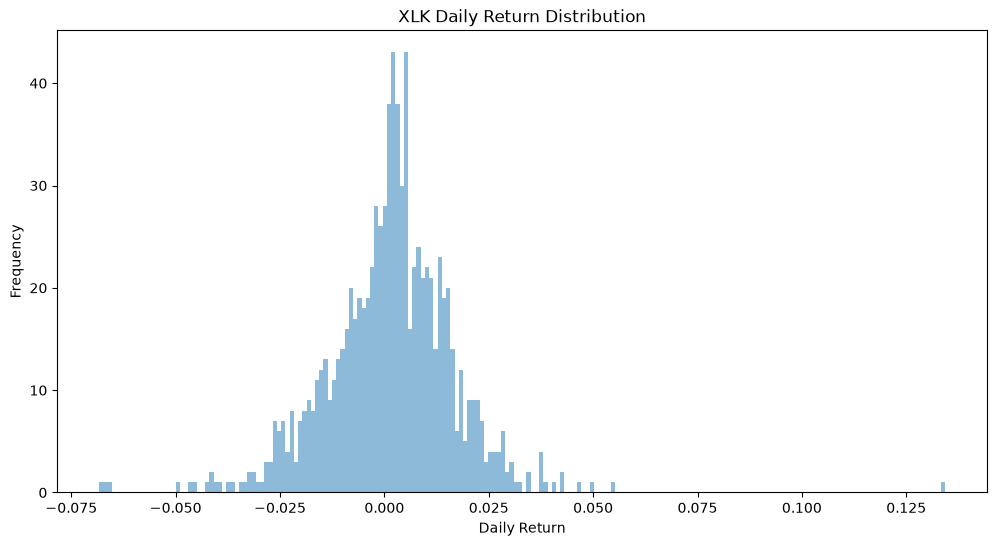

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.hist(xlk_return,bins=200,alpha=0.5,label='XLK')
plt.title('XLK Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.savefig("../figures/XLK_Daily_Return_Distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

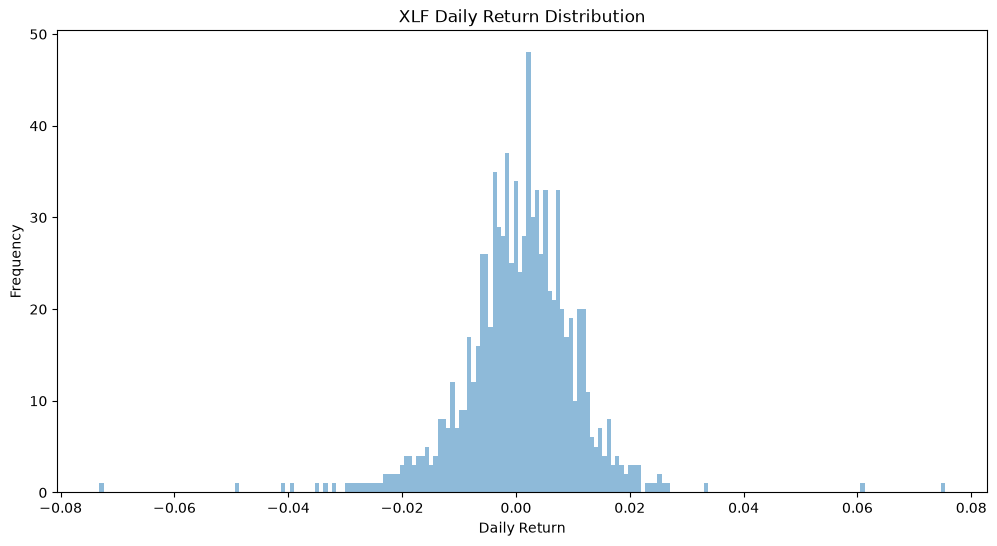

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.hist(xlf_return,bins=200,alpha=0.5,label='XLF')
plt.title('XLF Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.savefig("../figures/XLF_Daily_Return_Distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

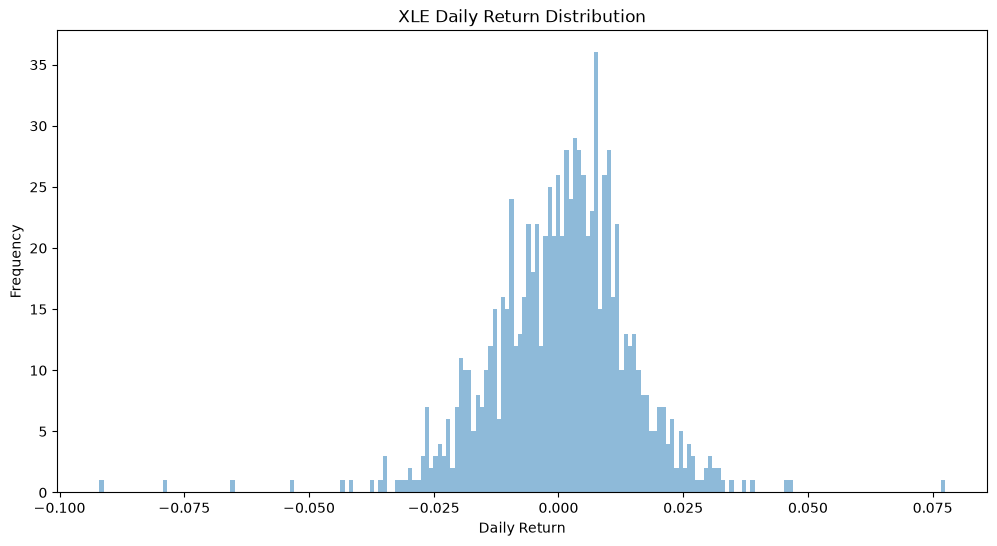

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.hist(xle_return,bins=200,alpha=0.5,label='XLE')
plt.title('XLE Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.savefig("../figures/XLE_Daily_Return_Distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

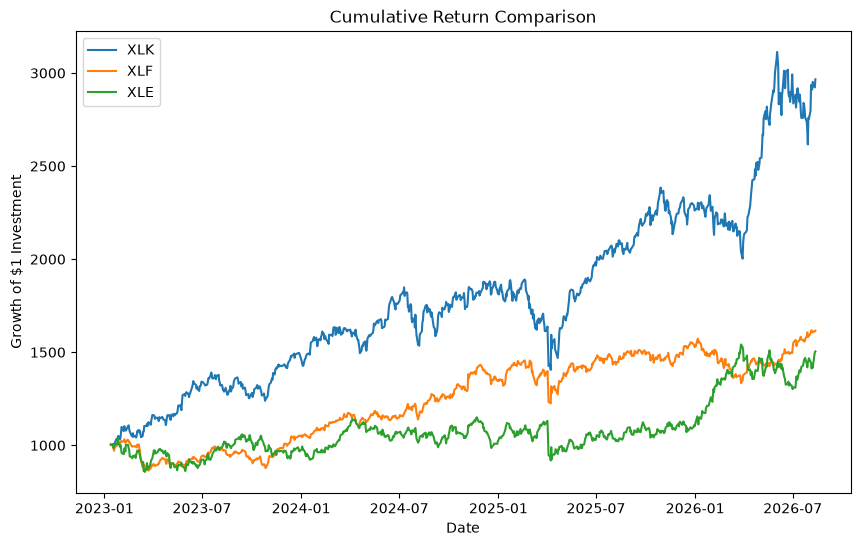

In [44]:
cumulative_returns = (1 + returns).cumprod()*1000


plt.figure(figsize=(10,6))

plt.plot(
    cumulative_returns["XLK"],
    label="XLK"
)

plt.plot(
    cumulative_returns["XLF"],
    label="XLF"
)

plt.plot(
    cumulative_returns["XLE"],
    label="XLE"
)


plt.title("Cumulative Return Comparison")

plt.xlabel("Date")

plt.ylabel("Growth of $1 Investment")

plt.legend()
plt.savefig("../figures/cumulative_return_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [45]:
Cumulative_Return_table_display = pd.DataFrame({
    "Initial Investment($)": ["$1,000", "$1,000", "$1,000"],
    "Final Value（$）": ["$3,000", "$1,600", "$1,500"],
    "Total Return（%）": ["+200%", "+60%", "+50%"],
    "Annual Volatility（%）": [
        "24.26%",
        "16.36%",
        "22.27%"
    ]
}, index=["XLK", "XLF", "XLE"])


Cumulative_Return_table_display

,Initial Investment($),Final Value（$）,Total Return（%）,Annual Volatility（%）
XLK,"$1,000","$3,000",+200%,24.26%
XLF,"$1,000","$1,600",+60%,16.36%
XLE,"$1,000","$1,500",+50%,22.27%


In [46]:
Cumulative_Return_table_display.to_csv(
    "../report/Cumulative_Return_table_display.csv"
)